<a href="https://colab.research.google.com/github/ManishSahani24/Quantum-Information-and-Computing/blob/main/Quantum%20Circuits.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
!pip -q install qiskit
!pip -q install qiskit-ibm-runtime
!pip -q install qiskit[visualization]
!pip install -q qiskit_aer
!pip install -q matplotlib numpy pylatexenc -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 111.7 MB/s eta 0:00:00


In [19]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.quantum_info import Statevector
from qiskit.circuit import Parameter
from qiskit.visualization import plot_histogram
from qiskit.visualization import plot_state_qsphere
import numpy as np
import matplotlib.pyplot as plt
import qiskit, qiskit_ibm_runtime, qiskit_aer

## 1. The Bell State (Maximally Entangled State)
The Bell state $|\Phi^+\rangle = \frac{1}{\sqrt{2}}(|00\rangle + |11\rangle)$ is the cornerstone of quantum information. It demonstrates perfect correlation between two qubits, a concept Einstein famously referred to as "spooky action at a distance."

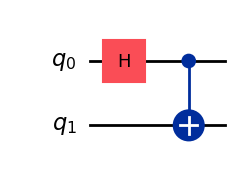

In [17]:

qc_bell = QuantumCircuit(2)
qc_bell.h(0)           # Create superposition on qubit 0
qc_bell.cx(0, 1)       # Entangle qubit 1 with qubit 0

qc_bell.draw('mpl')

## 2. Quantum Teleportation (Alice Bob)
Teleportation allows the transfer of a quantum state from one qubit to another without physically moving the particle, using a shared Bell state and classical communication.

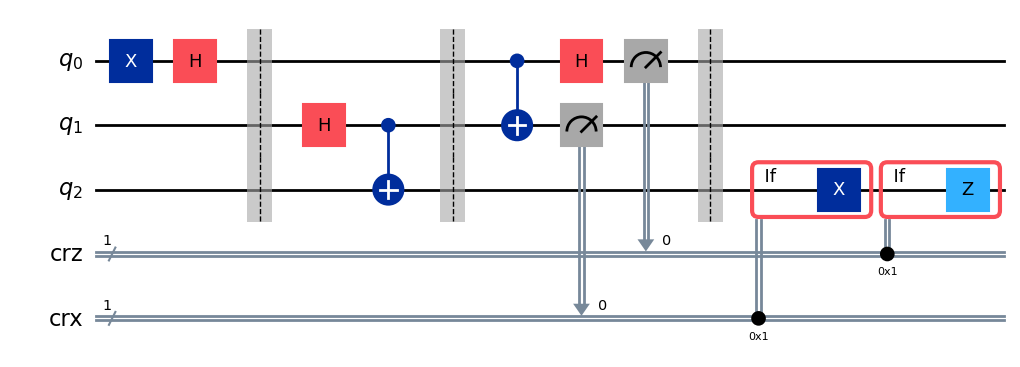

In [24]:
qr = QuantumRegister(3, name="q")
crz = ClassicalRegister(1, name="crz")
crx = ClassicalRegister(1, name="crx")
qc_teleport = QuantumCircuit(qr, crz, crx)

# Step 1: Alice has a state she wants to teleport (e.g., state |->)
qc_teleport.x(0)
qc_teleport.h(0)
qc_teleport.barrier()

# Step 2: Create entangled pair between Alice (q1) and Bob (q2)
qc_teleport.h(1)
qc_teleport.cx(1, 2)
qc_teleport.barrier()

# Step 3: Alice performs Bell measurement
qc_teleport.cx(0, 1)
qc_teleport.h(0)
qc_teleport.measure(0, crz)
qc_teleport.measure(1, crx)
qc_teleport.barrier()

# Step 4: Bob applies conditional operations using modern dynamic circuit syntax
with qc_teleport.if_test((crx, 1)):
    qc_teleport.x(2)

with qc_teleport.if_test((crz, 1)):
    qc_teleport.z(2)

qc_teleport.draw('mpl')

## 3. Grover's Algorithm (2-Qubit Search)
Grover's algorithm provides a quadratic speedup for searching unstructured databases. It relies on amplitude amplification to increase the probability of measuring the correct state.

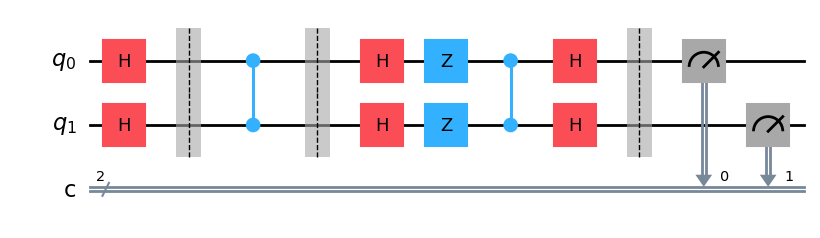

In [25]:
# Searching for state |11>
qc_grover = QuantumCircuit(2, 2)

# State preparation
qc_grover.h([0, 1])
qc_grover.barrier()

# Oracle for |11> (A simple CZ gate)
qc_grover.cz(0, 1)
qc_grover.barrier()

# Diffuser (Amplitude Amplification)
qc_grover.h([0, 1])
qc_grover.z([0, 1])
qc_grover.cz(0, 1)
qc_grover.h([0, 1])
qc_grover.barrier()

# Measurement
qc_grover.measure([0, 1], [0, 1])

qc_grover.draw('mpl')